# 옵티마이져 성능 비교  iris 분류

In [22]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch

scaler = StandardScaler()
iris = load_iris()
X = iris.data
y = iris.target

x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y,random_state=42)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train_t = torch.FloatTensor(x_train)
y_train_t = torch.LongTensor(y_train)

train_dataset = TensorDataset(x_train_t,y_train_t)
train_loader = DataLoader(train_dataset,batch_size=24)

class RegressionIris(nn.Module):
    def __init__(self, input_dim, hidden_dim,output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = nn.ReLU()(self.fc1(x))
        x = nn.ReLU()(self.fc2(x))
        output = self.fc3(x)
        return output

In [23]:
# 다중분류 크로스엔트로피로스
from torch.optim import SGD,Adagrad,RMSprop,Adam
model = RegressionIris(4, 16, 3)
criterion = nn.CrossEntropyLoss()

In [24]:
from tqdm import tqdm
epochs = 200; loss_list = []
sgd = SGD(model.parameters(),momentum=0)
for epoch in tqdm(range(epochs)):
    total_loss = 0.0
    for x,y in train_loader:
        sgd.zero_grad()
        predict = model(x)
        loss = criterion(predict, y)
        loss.backward()
        sgd.step()

        total_loss += loss.item()
    loss_list.append(total_loss / len(train_loader))
print(loss_list)    

100%|██████████| 200/200 [00:01<00:00, 123.58it/s]

[1.1017863273620605, 1.1012807607650756, 1.1007707595825196, 1.100253415107727, 1.099734377861023, 1.0992171049118042, 1.098700761795044, 1.0981843948364258, 1.0976679801940918, 1.0971532583236694, 1.096640682220459, 1.0961289882659913, 1.0956185102462768, 1.0951080560684203, 1.094599199295044, 1.0940917491912843, 1.0935837030410767, 1.0930755853652954, 1.0925675630569458, 1.0920597791671753, 1.0915531635284423, 1.09104266166687, 1.0905292272567748, 1.0900149822235108, 1.0894974946975708, 1.0889723300933838, 1.088449192047119, 1.0879248142242433, 1.08739492893219, 1.0868645668029786, 1.0863335371017455, 1.0858020305633544, 1.0852704763412475, 1.0847395181655883, 1.0842100858688355, 1.0836835622787475, 1.0831565856933594, 1.082629179954529, 1.0821012496948241, 1.0815720796585082, 1.0810420751571654, 1.0805113315582275, 1.0799799680709838, 1.0794474840164185, 1.078915047645569, 1.078383493423462, 1.077852463722229, 1.0773206949234009, 1.0767882823944093, 1.0762540340423583, 1.07571752071

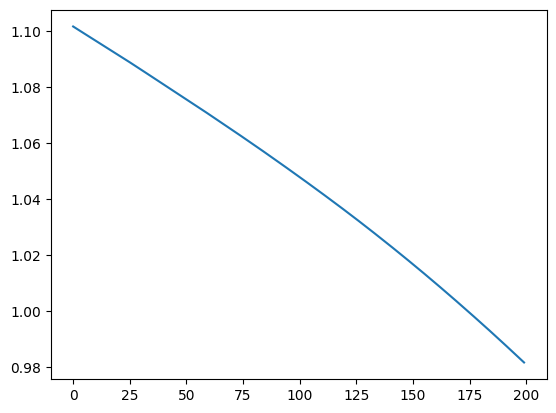

In [25]:
import matplotlib.pyplot as plt
plt.plot(range(epochs), loss_list)